In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
from pathlib import Path
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor


sys.path.append(str(Path.cwd().parent))

from src.data.features.build_features import add_lagged_returns, add_log_returns, add_log_rolling_volatility, add_rolling_z_score, add_rsi, load_prices_long
from src.data.targets.build_targets import add_volatility_target, add_direction_target
from src.models.evaluation import evaluate_predictions, walk_forward_folds, run_walk_forward, get_walk_forward_predictions
from src.backtest.backtest import run_backtest, compute_backtest_metrics
from src.backtest.position_sizing import compute_position_size


In [2]:
tickers = ['SPY','GOOG', 'NVDA', 'NFLX', 'MSFT']
df = load_prices_long("../data/raw_prices.parquet", tickers)
df.head()

Price,date,open,high,low,close,volume,ticker
0,2020-01-02,294.912997,296.143553,293.992353,296.125305,59151200,SPY
1,2020-01-03,292.743535,295.004113,292.688847,293.882935,77709700,SPY
2,2020-01-06,292.132782,295.086123,292.014280,295.004089,55653900,SPY
3,2020-01-07,294.438973,294.912981,293.727989,294.174652,40496400,SPY
4,2020-01-08,294.366059,296.954771,294.119959,295.742462,68296000,SPY


In [3]:
df = add_log_returns(df)
df = add_log_rolling_volatility(df, [5, 10, 20])
df = add_rsi(df, [14])
df = add_volatility_target(df, [5])

In [4]:
feature_cols = ['vol_5d', 'vol_10d', 'vol_20d', 'rsi_14d'] 
target_col = 'target_vol_5d'

In [5]:
# Generates oos predictions across folds
pred_df = get_walk_forward_predictions(
    df=df, 
    feature_cols=feature_cols, 
    target_col=target_col, 
    model_factory=lambda: XGBRegressor(n_estimators=100, max_depth=3),
    train_size=252,
    test_size=21
)

In [6]:
# Scale predictions into positions
pred_df['position'] = compute_position_size(
    pred_df['predicted_log_vol'], target_vol=0.15, max_leverage=2.0
)

pred_df['simple_return'] = np.exp(pred_df['log_return']) - 1

# Executes backtesting
backtest_results = run_backtest(
    df=pred_df, position_col='position', return_col='simple_return', cost_bps=5.0
)

In [7]:
# Collapse tickers into one row per data, sorter chronologically so metrics aren't looking at everything all together
portfolio_returns = backtest_results.groupby('date')['net_return'].mean().sort_index()

# Computes metrics
strategy_metrics = compute_backtest_metrics(portfolio_returns)
strategy_metrics

Annualized Return    0.003185
Sharpe               1.036391
Max_Drawdown        -0.311610
Calmar ratio         0.010222
dtype: float64

In [8]:
# Buy and hold benchmark on same oos test
pred_df["benchmark_position"] = 1.0

benchmark_results = run_backtest(
    df=pred_df,
    position_col="benchmark_position",
    return_col="simple_return",
    cost_bps=0.0,
)
benchmark_returns = benchmark_results.groupby('date')['net_return'].mean().sort_index()

benchmark_metrics = compute_backtest_metrics(benchmark_returns)

print("\nBuy & Hold Baseline Metrics:")
benchmark_metrics


Buy & Hold Baseline Metrics:


Annualized Return    0.005375
Sharpe               1.062115
Max_Drawdown        -0.460479
Calmar ratio         0.011672
dtype: float64

In [9]:
def plot_backtest_results(backtest_results: pd.DataFrame, benchmark_results=pd.DataFrame):
    # Aggregate daily portfolio return for our strategy and benchmark
    strat_daily = backtest_results.groupby('date')['net_return'].mean()
    bench_daily = benchmark_results.groupby('date')['net_return'].mean()
    
    # Calculate drawdown
    strat_cum = (1 + strat_daily).cumprod()
    bench_cum = (1 + bench_daily).cumprod()
    
    strat_peak = strat_cum.cummax()
    strat_dd = (strat_cum - strat_peak) / strat_peak
    
    bench_peak = bench_cum.cummax()
    bench_dd = (bench_cum - bench_peak) / bench_peak    
    
    # Aggregate turnover
    avg_turnover = backtest_results.groupby('date')['turnover'].mean()
    
    fig, axes = plt.subplots(
        3, 1, figsize=(12,10), sharex=True, gridspec_kw={'height_ratios': [3, 1.5, 1]}
    )
    
    # Subplot 1: Cumulative equity curve
    axes[0].plot(
        strat_cum.index,
        strat_cum.values,
        label='XGBoost Vol-Targeted Strategy',
        color='blue',
        linewidth=2
    )
    axes[0].plot(
        bench_cum.index,
        bench_cum.values,
        label='Buy & Hold Benchamrk',
        color='red',
        linewidth=2
    )
    axes[0].set_title('Walk-Forward Backtest Performance')
    axes[0].set_ylabel('Portfolio Value')
    axes[0].legend(loc='upper left')
    axes[0].grid(True, alpha=0.3)
    
    axes[1].plot(
        strat_dd.index,
        strat_dd.values,
        label='Strategy Drawdown',
        color='blue',
        linewidth=2
    )
    axes[1].plot(
        bench_dd.index,
        bench_dd.values,
        label='Benchmark Drawdown',
        color='red',
        linewidth=2
    )
    
    axes[1].set_ylabel("Drawdown")
    axes[1].legend(loc="lower left")
    axes[1].grid(True, alpha=0.3)
    
    # Subplot 3: Daily Turnover
    axes[2].bar(
        avg_turnover.index,
        avg_turnover.values,
        color="green",
        alpha=0.6,
        width=1.5,
        label="Average Daily Turnover",
    )
    axes[2].set_ylabel("Turnover")
    axes[2].set_xlabel("Date")
    axes[2].legend(loc="upper left")
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    

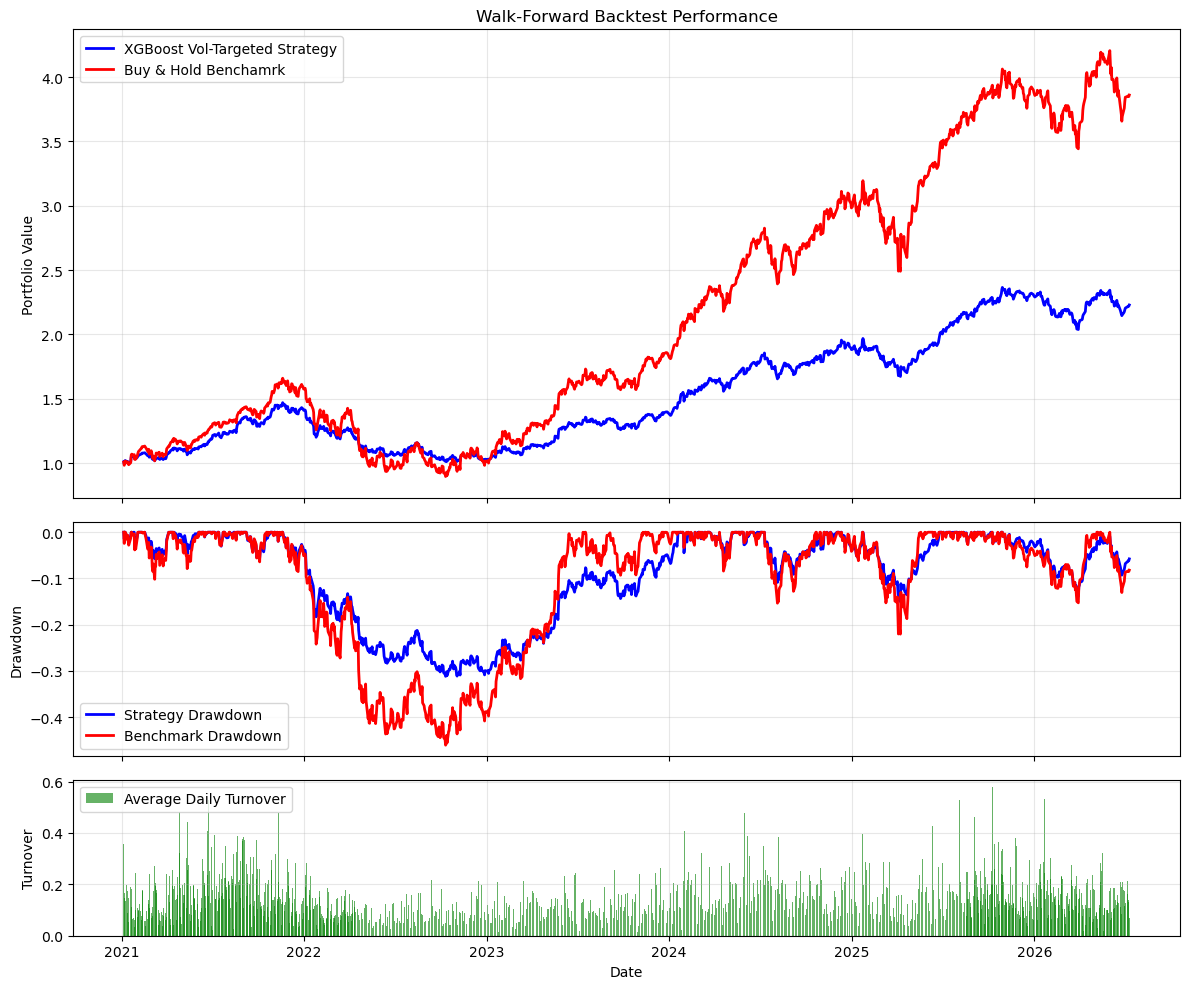

In [10]:
plot_backtest_results(backtest_results, benchmark_results)

In [14]:
# Same thing we did with XGBoost, but with linear regression
lin_reg_df = get_walk_forward_predictions(
    df=df, 
    feature_cols=feature_cols, 
    target_col=target_col, 
    model_factory=lambda: LinearRegression(),
    train_size=252,
    test_size=21
)

# Scale predictions into positions
lin_reg_df['position'] = compute_position_size(
    lin_reg_df['predicted_log_vol'], target_vol=0.15, max_leverage=2.0
)

lin_reg_df['simple_return'] = np.exp(lin_reg_df['log_return']) - 1

# Executes backtesting
lin_reg_backtest_results = run_backtest(
    df=lin_reg_df, position_col='position', return_col='simple_return', cost_bps=5.0
)
# Collapse tickers into one row per data, sorter chronologically so metrics aren't looking at everything all together
lin_reg_portfolio_returns = lin_reg_backtest_results.groupby('date')['net_return'].mean().sort_index()

# Computes metrics
lin_reg_strategy_metrics = compute_backtest_metrics(lin_reg_portfolio_returns)
lin_reg_strategy_metrics

Annualized Return    0.003304
Sharpe               1.099763
Max_Drawdown        -0.268862
Calmar ratio         0.012288
dtype: float64

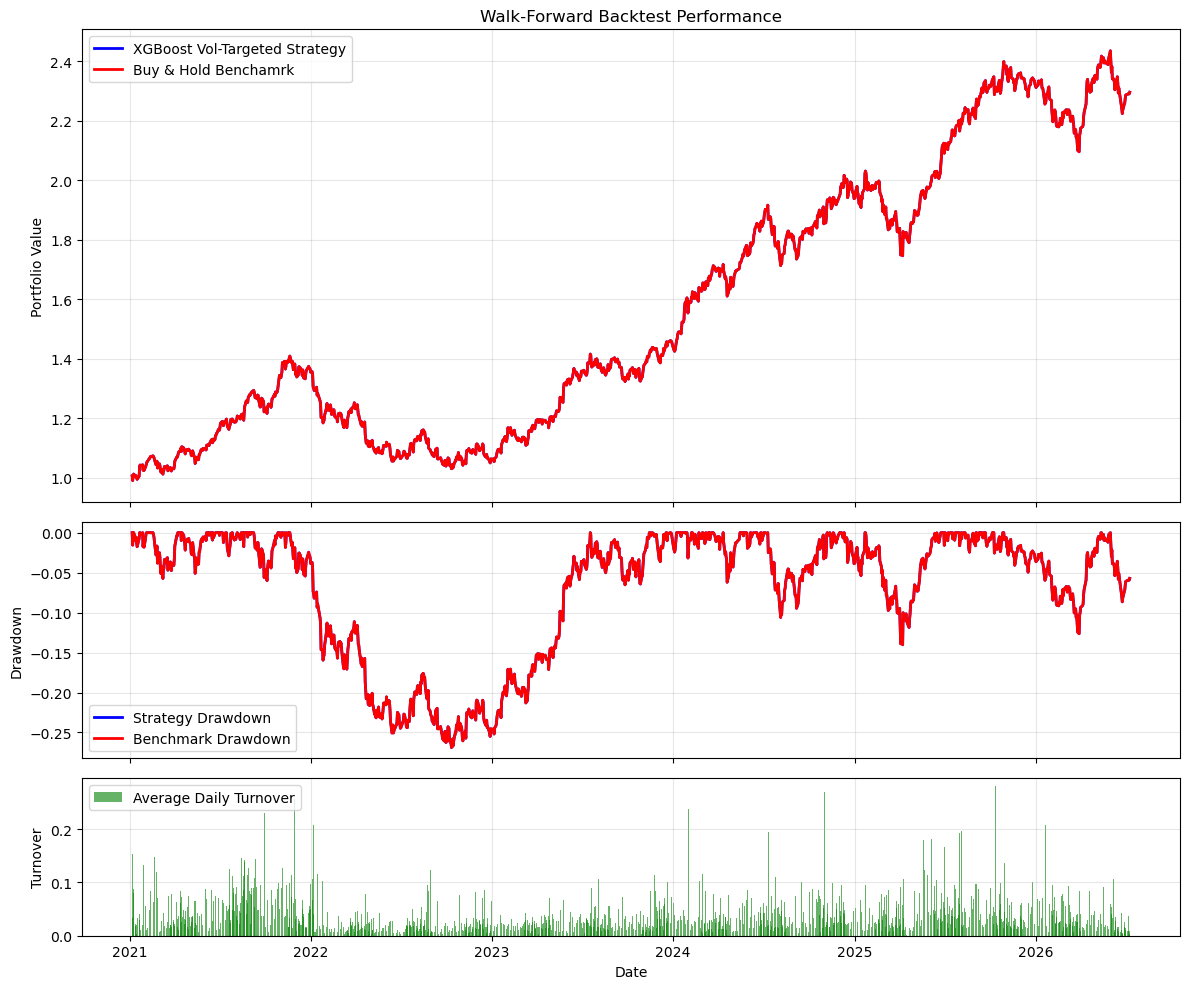

In [15]:
plot_backtest_results(backtest_results, lin_reg_backtest_results)